# OpenAI Cookbook Clustering with Downloaded Food Reviews

This notebook uses the downloaded `fine_food_reviews_with_embeddings_1k.csv` dataset in `/workspace/data`.

It does four things:

- loads the local CSV
- parses the precomputed embeddings already stored in the `embedding` column
- runs KMeans clustering and t-SNE over the full 1000-review dataset
- inserts a balanced subset into local Weaviate and runs `collection.cluster()` through the worker container


In [12]:
import os
from ast import literal_eval
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import weaviate
from IPython.display import Image, display
from celery.result import AsyncResult
from openai import OpenAI
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from weaviate.classes.config import Configure, DataType, Property
from weaviate.dotproduct import DotproductStore

from app.celery_app import celery_app

DATASET_PATH = Path("/workspace/data/fine_food_reviews_with_embeddings_1k.csv")
LABEL_MODEL = os.getenv("OPENAI_CLUSTER_LABEL_MODEL", "gpt-4.1-mini")
USE_OPENAI = bool(os.getenv("OPENAI_API_KEY"))
openai_client = OpenAI() if USE_OPENAI else None

print({
    "dataset_path": str(DATASET_PATH),
    "dataset_exists": DATASET_PATH.exists(),
    "using_openai_for_cluster_naming": USE_OPENAI,
    "label_model": LABEL_MODEL,
})


{'dataset_path': '/workspace/data/fine_food_reviews_with_embeddings_1k.csv', 'dataset_exists': True, 'using_openai_for_cluster_naming': False, 'label_model': 'gpt-4.1-mini'}


In [13]:
df = pd.read_csv(DATASET_PATH)
df = df.rename(columns={"": "row_id", "Unnamed: 0": "row_id"})
df["embedding"] = df["embedding"].apply(literal_eval).apply(np.array)
df["Score"] = df["Score"].astype(int)
df["n_tokens"] = df["n_tokens"].astype(int)

matrix = np.vstack(df["embedding"].values)

display(df[["row_id", "ProductId", "Score", "Summary", "n_tokens"]].head())
matrix.shape


,row_id,ProductId,Score,Summary,n_tokens
0,0,B003XPF9BO,5,where does one start...and stop... with a tre...,52
1,297,B003VXHGPK,4,"Good, but not Wolfgang Puck good",178
2,296,B008JKTTUA,1,Should advertise coconut as an ingredient more...,78
3,295,B000LKTTTW,5,Best tomato soup,111
4,294,B001D09KAM,1,Should advertise coconut as an ingredient more...,78


(1000, 1536)

In [14]:
n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    init="k-means++",
    n_init=10,
    random_state=42,
)

df["Cluster"] = kmeans.fit_predict(matrix)

display(df.groupby("Cluster").Score.mean().sort_values().to_frame("mean_score"))
display(df.groupby("Cluster").size().sort_values(ascending=False).to_frame("count"))


,mean_score
Cluster,
0,2.243902
2,4.194030
3,4.516529
1,4.769565


,count
Cluster,
1,460
3,242
0,164
2,134


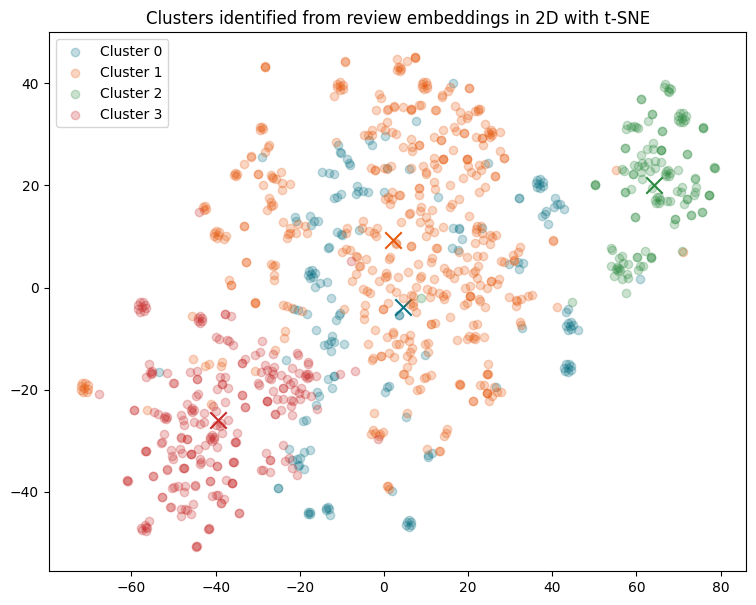

In [15]:
tsne = TSNE(
    n_components=2,
    perplexity=15,
    random_state=42,
    init="random",
    learning_rate=200,
)
vis_dims = tsne.fit_transform(matrix)

x = vis_dims[:, 0]
y = vis_dims[:, 1]
colors = ["#0b7285", "#e8590c", "#2b8a3e", "#c92a2a", "#6741d9", "#495057"]

plt.figure(figsize=(9, 7))
for cluster_id in range(n_clusters):
    xs = x[df.Cluster == cluster_id]
    ys = y[df.Cluster == cluster_id]
    color = colors[cluster_id % len(colors)]
    plt.scatter(xs, ys, color=color, alpha=0.25, label=f"Cluster {cluster_id}")
    plt.scatter(xs.mean(), ys.mean(), marker="x", color=color, s=140)

plt.title("Clusters identified from review embeddings in 2D with t-SNE")
plt.legend()
plt.show()


In [16]:
def sampled_cluster_reviews(cluster_id: int, sample_size: int = 5) -> pd.Series:
    return (
        df[df.Cluster == cluster_id]
        .combined.str.replace("Title: ", "", regex=False)
        .str.replace("; Content: ", ": ", regex=False)
        .sample(sample_size, random_state=42)
    )


cluster_themes = {}
for cluster_id in range(n_clusters):
    reviews = "\n".join(sampled_cluster_reviews(cluster_id).tolist())
    if USE_OPENAI:
        response = openai_client.responses.create(
            model=LABEL_MODEL,
            input=(
                "What do the following customer reviews have in common? "
                "Return a short theme of at most eight words.\n\n"
                f"Customer reviews:\n{reviews}"
            ),
        )
        theme = response.output_text.strip()
    else:
        theme = f"Cluster {cluster_id}"

    cluster_themes[cluster_id] = theme
    print(f"Cluster {cluster_id} theme: {theme}")
    display(df[df.Cluster == cluster_id][["Score", "Summary"]].sample(5, random_state=42))


Cluster 0 theme: Cluster 0


,Score,Summary
845,1,Disappointed
719,3,Pouch was ripped
809,4,Busted
311,3,ok....not the best
615,1,Expensive


Cluster 1 theme: Cluster 1


,Score,Summary
265,5,Great taste!
64,4,Good quality grinder
458,4,good deal
954,5,Great!
335,5,Prefect fusion


Cluster 2 theme: Cluster 2


,Score,Summary
962,5,Dogs love it.
460,5,The BEST dog candy
800,3,Our dogs love it but finding low price and 12 ...
146,5,My dogs love them!
304,5,Lab puppy loves it


Cluster 3 theme: Cluster 3


,Score,Summary
116,5,Monin Syrups Raspberry Tea
67,5,I couldn't love the double bergamot more
592,5,Morning Coffee
849,5,"Works great, simple install."
976,5,Love It


## Send a balanced subset into local Weaviate

The local clustering above uses all 1000 embedded reviews.

For the Weaviate plus worker demonstration, the notebook inserts a balanced subset of 40 reviews from each local cluster. This keeps the notebook responsive while still exercising the patched `collection.insert(...)` and `collection.cluster(...)` flow end to end.


In [17]:
reviews_per_cluster_for_weaviate = 40
weaviate_df = pd.concat(
    [
        part.sample(min(reviews_per_cluster_for_weaviate, len(part)), random_state=42)
        for _, part in df.groupby("Cluster")
    ],
    ignore_index=True,
)

display(weaviate_df.groupby("Cluster").size().to_frame("rows_for_weaviate"))


,rows_for_weaviate
Cluster,
0,40
1,40
2,40
3,40


In [18]:
client = weaviate.connect_to_dotproduct_local()
collection_name = "CookbookFoodReviews"
reviews = client.collections.use(collection_name)

if reviews.exists():
    client.collections.delete(collection_name)

client.collections.create(
    name=collection_name,
    properties=[
        Property(name="row_id", data_type=DataType.INT),
        Property(name="product_id", data_type=DataType.TEXT),
        Property(name="user_id", data_type=DataType.TEXT),
        Property(name="score", data_type=DataType.INT),
        Property(name="summary", data_type=DataType.TEXT),
        Property(name="review_text", data_type=DataType.TEXT),
        Property(name="cluster_theme", data_type=DataType.TEXT),
        Property(name="local_cluster", data_type=DataType.INT),
    ],
    vector_config=Configure.Vectors.self_provided(),
)
reviews = client.collections.use(collection_name)

inserted_uuids = []
for row in weaviate_df.itertuples(index=False):
    inserted_uuid = reviews.insert(
        properties={
            "row_id": int(row.row_id),
            "product_id": row.ProductId,
            "user_id": row.UserId,
            "score": int(row.Score),
            "summary": row.Summary,
            "review_text": row.Text,
            "cluster_theme": cluster_themes[int(row.Cluster)],
            "local_cluster": int(row.Cluster),
        },
        vector=row.embedding.tolist(),
        metadata={
            "source_csv": DATASET_PATH.name,
            "n_tokens": int(row.n_tokens),
            "local_cluster": int(row.Cluster),
        },
    )
    inserted_uuids.append(str(inserted_uuid))

insert_summary = {
    "collection": collection_name,
    "inserted_objects": len(inserted_uuids),
}
display(insert_summary)
inserted_uuids[:5]


/workspace/vendor/weaviate-python-client/weaviate/warnings.py:93: DeprecationWarning: Dep005: You are using weaviate-client version 0.1.dev1+g10652f8cf.d20260321. The latest version is 4.20.4.
            Consider upgrading to the latest version. See https://weaviate.io/developers/weaviate/client-libraries/python for details.
  warnings.warn(


160

In [19]:
submission = reviews.cluster(limit=len(weaviate_df), params={"k": n_clusters, "plot": True})
submission_payload = {
    "workload_id": submission.workload_id,
    "task_id": submission.task_id,
    "collection": submission.collection,
    "status": submission.status,
    "candidate_count": len(submission.uuids),
}
display(submission_payload)
submission_payload


ClusterSubmission(workload_id='0fdab7dc-bcaf-4992-92bf-a23e6692813b', task_id='7613b0b6-8eb6-4ded-a0bd-12917f7f65d5', collection='CookbookFoodReviews', uuids=['007daf23-ba68-4822-9db8-58a212742716', '0143ff34-c631-43b2-8efc-0e055b3e827b', '0332b6ce-4eb8-41e2-99aa-b740bf407f5c', '03e2ac40-4b21-4d4b-8429-9595e6bf95a6', '046546a4-abc7-4515-bd9d-c7f796f97ac7', '048360f8-6c38-406c-9398-55806d4ec0b7', '06eca742-0c9b-4da0-b636-7d94f0a30fbf', '0a019be9-fefe-4126-8037-4ca0b6ac4a53', '0bc637d3-c43b-4fcf-9869-32cfd1dc3b3f', '0c9a9319-e2ad-48a0-ad62-3947c552c23d', '0f0bbb54-e6ff-4c25-a233-c36c64c1377e', '0f4f14f8-9a68-4bda-9a51-2efb450587e3', '0ff2604b-ab35-4017-90ff-11ea88cebf58', '102c83a5-2ac7-472b-926f-74a2a398e761', '13010c57-c514-4377-b19e-4c52aff6aae8', '17265ddf-3dd4-4ff4-a38c-b37675c5196d', '1871dd92-990a-40b6-a68b-1060b32db30a', '203553ac-a3dc-42eb-b107-0d05fce9cc5d', '2109ee7b-46e1-4c24-840a-85dc8800e6b2', '2558a9f9-b2c1-4cf6-965f-fd10cfecfef5', '25ef85eb-7933-4afd-82d4-0f9dfae403a8', '

In [20]:
task = AsyncResult(submission.task_id, app=celery_app)
task_result = task.get(timeout=60)
display(task_result)
pprint(task_result)


{'algorithm': 'kmeans',
 'cluster_sizes': {'0': 32, '1': 46, '2': 39, '3': 43},
 'n_clusters': 4,
 'workload_id': '0fdab7dc-bcaf-4992-92bf-a23e6692813b'}


In [21]:
store = DotproductStore()
workload = store.get_workload(submission.workload_id)
cluster_results = pd.DataFrame(store.get_cluster_results(submission.workload_id))
plot_artifact = store.get_workload_artifact(submission.workload_id, "cluster_plot")

result_df = weaviate_df.copy()
result_df["uuid"] = inserted_uuids
result_df = result_df.merge(cluster_results[["uuid", "cluster_id"]], on="uuid", how="left")
result_df = result_df.rename(columns={"Cluster": "local_cluster", "Summary": "summary"})

comparison = pd.crosstab(result_df["local_cluster"], result_df["cluster_id"])

display(workload)
display(plot_artifact["metadata"])
display(Image(data=plot_artifact["artifact_blob"]))
display(cluster_results.head(20))
display(comparison)
display(result_df[["summary", "Score", "local_cluster", "cluster_id"]].sort_values(["cluster_id", "local_cluster", "Score"], ascending=[True, True, False]).head(20))

client.close()


{'workload_id': '0fdab7dc-bcaf-4992-92bf-a23e6692813b',
 'collection': 'CookbookFoodReviews',
 'tenant': None,
 'kind': 'cluster',
 'algorithm': 'kmeans',
 'status': 'completed',
 'executor_task_id': '7613b0b6-8eb6-4ded-a0bd-12917f7f65d5',
 'created_at': '2026-03-21T16:08:09.662640+00:00',
 'updated_at': '2026-03-21T16:08:10.414631+00:00',
 'params': {'k': 4},
 'query': {'type': 'fetch_objects', 'limit': 160}}

cluster_id,0,1,2,3
local_cluster,,,,
0,30,10,0,0
1,1,34,0,5
2,1,0,39,0
3,0,2,0,38


,summary,Score,local_cluster,cluster_id
13,This is a big container.,5,0,0
2,Busted,4,0,0
19,yummy cookies!,4,0,0
27,yummy cookies!,4,0,0
31,"Delicious, but lid is cheap",4,0,0
38,not enough,4,0,0
1,Pouch was ripped,3,0,0
6,The Kind Plus item was sticky,3,0,0
14,cats dont like,3,0,0
21,Great Cereal Ridiculous Price,3,0,0
